# 00 - Setup and Data

Project: Critical Stations - centrality and resilience in Israel's public transport network

Israel's national public transport is published by the Ministry of Transport as a GTFS feed (General Transit Feed Specification): a set of CSV text files describing every operator, route, trip, stop and scheduled stop time in the country. That feed is really a graph. If we treat each stop as a node and connect two stops whenever some scheduled trip runs directly from one to the other, we get a national mobility network of about 30,000 nodes and 52,000 edges.

This notebook series asks two questions about that network:

1. Which stations are critical? Which stations carry a disproportionate share of the country's connectivity, measured by degree, weighted degree, PageRank, betweenness, articulation points and bridges?
2. How resilient is the network to losing stations? If the top-ranked stations are removed (a flood, a security event, a strike, construction work), how fast does the network fall apart compared to losing random stations?

This first notebook is the entry point. It does no graph theory at all. Its job is to show the environment works, pull the one large data file that isn't tracked in git onto disk, and give the reader an honest inventory of the raw data everything else is built on.

Input

- `israel-public-transportation/` - the GTFS feed shipped with the repository (`agency.txt`, `calendar.txt`, `fare_attributes.txt`, `fare_rules.txt`, `routes.txt`, `stops.txt`, `translations.txt`, `trips.txt`)
- `stop_times.txt` (816 MB) - not in git; downloaded on demand from Google Drive

Output (all under `outputs/nb/00_setup_and_data/`)

- `tables/gtfs_file_inventory.csv` - every file in the feed with its size, row count and role
- `tables/route_type_distribution.csv` - number of routes per GTFS `route_type`
- `tables/agency_route_counts.csv` - number of routes per operator
- `tables/service_calendar_summary.csv` - service days by day of week
- `feed_manifest.json` - a machine-readable summary the later notebooks read
- `figures/route_type_distribution.png`, `figures/routes_per_agency.png`, `figures/stop_locations.png`

Depends on: nothing. This is stage 00, run it first.

Runtime: a few seconds, plus a one-time download of about 816 MB if `stop_times.txt` is missing.

## 1. Setting up the environment

The cell below is the only piece of boilerplate in the project, and it repeats verbatim at the top of every notebook. It does three things:

- `_ensure(...)` installs a package only if the import can't be resolved, so re-running a notebook on a machine that's already set up costs nothing and never touches the network.
- `find_repo_root()` climbs up from the current directory looking for the `israel-public-transportation/` folder. That lets the notebook work whether you start Jupyter from the repository root, from inside `notebooks/`, or anywhere else. If the folder isn't found, which is what happens on a fresh Google Colab runtime, the code clones the public repository into `/content` instead. So a reviewer needs nothing beyond this notebook and an internet connection.
- It fixes the working directory and sets `DATA` (the raw feed) and `OUT` (the notebook's output root), so every cell below can use `Path` objects instead of relative paths.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Repo root: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר


## 2. Dependencies and version check

The whole project runs on a small, ordinary scientific-Python stack: pandas for the CSV tables, numpy for the numeric work, matplotlib for the figures, and networkx for the graph work in the later notebooks. We install them here (a no-op if they already exist) and then print the versions.

Printing the versions isn't decoration. It's the fastest way for a reviewer to see the environment is actually live, and if some result doesn't reproduce later, the version line is the first thing to compare.

In [2]:
_ensure("pandas", "numpy", "matplotlib", "networkx")

import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("python     ", sys.version.split()[0])
print("pandas     ", pd.__version__)
print("numpy      ", np.__version__)
print("matplotlib ", matplotlib.__version__)
print("networkx   ", nx.__version__)
print("\nData dir exists:", DATA.is_dir(), "->", DATA)

python      3.10.11
pandas      2.3.3
numpy       1.26.4
matplotlib  3.10.9
networkx    3.4.2

Data dir exists: True -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\israel-public-transportation


## 3. Output conventions and runtime switches

Every notebook in the series writes to its own stage folder under `outputs/nb/`, and reads earlier stages from theirs. The `outputs/` tree is regenerated on every run and isn't tracked in git.

Two constants control the only non-trivial cost in this notebook:

- `COUNT_ROWS` - counting the rows of `stop_times.txt` means streaming 816 MB from disk (roughly 5-30 seconds, depending on the drive). Set it to `False` for an instant run; the inventory then reports the row count as `NaN` for that one file.
- `PREVIEW_ROWS` / `TOP_AGENCIES` - cosmetic display limits only.

In [3]:
STAGE = OUT / "00_setup_and_data"
(STAGE / "tables").mkdir(parents=True, exist_ok=True)
(STAGE / "figures").mkdir(parents=True, exist_ok=True)

# --- run-time switches -------------------------------------------------------
COUNT_ROWS = True      # False -> skip the ~816 MB scan of stop_times.txt
PREVIEW_ROWS = 5       # rows shown in each preview table
TOP_AGENCIES = 12      # bars in the "routes per operator" figure

print("Stage output folder:", STAGE)

Stage output folder: C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\00_setup_and_data


## 4. Fetching the raw feed (`stop_times.txt`)

Eight of the nine GTFS files are small enough to live in the repository. The ninth, `stop_times.txt`, weighs 816 MB - one row per scheduled arrival at every stop in the country, about 15.7 million rows - and git isn't the right place for it. The file lives on Google Drive and is pulled on demand with `gdown`.

This file is the raw material of the graph: consecutive rows sharing the same `trip_id` are exactly the "the vehicle went straight from stop A to stop B" events that become edges in notebook 02. The download runs once; on every later run an `exists()` check skips it.

In [4]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 5. Hebrew text in figures

Every stop name, route description and operator name in this feed is in Hebrew, and Hebrew is written right to left. Matplotlib renders a string in logical order (storage order) and doesn't apply the Unicode bidirectional algorithm, so a Hebrew label drawn naively comes out with its letters reversed and unreadable to anyone who actually reads Hebrew.

The fix is to reorder the characters into display order before they reach the renderer, using `python-bidi`. Instead of remembering to wrap every label by hand, we monkey-patch `matplotlib.text.Text.set_text` once so that every Hebrew string is converted automatically, everywhere: axis labels, titles and annotations. The patch is idempotent (guarded by `_bidi_patched`) and leaves non-Hebrew text unchanged.

In [5]:
# Stop names are Hebrew. Whether they render reversed depends on the matplotlib build:
# most builds do NOT apply the Unicode bidi algorithm (so Hebrew must be reordered with
# python-bidi), but libraqm/raqm builds (some Colab installs, newer wheels) apply bidi
# themselves. We detect what THIS matplotlib does and only reorder when it does not, so
# labels render correctly on every environment and are never double-reversed.
_ensure("python-bidi")
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext
from bidi.algorithm import get_display

def _mpl_reorders_hebrew():
    """True if matplotlib already applies the bidi algorithm itself (so get_display must NOT be applied)."""
    try:
        from matplotlib.figure import Figure
        from matplotlib.backends.backend_agg import FigureCanvasAgg
        def _ink_cols(s):
            fig = Figure(figsize=(3, 1), dpi=100)
            FigureCanvasAgg(fig)
            ax = fig.add_axes([0, 0, 1, 1])
            ax.axis("off")
            ax.text(0.5, 0.5, s, fontsize=32, ha="center", va="center")
            fig.canvas.draw()
            prof = (np.asarray(fig.canvas.buffer_rgba())[:, :, :3].mean(2) < 128).sum(0).astype(float)
            nz = np.where(prof > 0)[0]
            return prof[nz.min():nz.max() + 1] if len(nz) else prof
        # Probe: Hebrew letters then digits. The digits are logically LAST, so in plain
        # logical order they render on the RIGHT; if matplotlib applies bidi they move LEFT.
        probe = _ink_cols("אבג12")
        tmpl = _ink_cols("12")
        n = len(tmpl)
        if n < 2 or len(probe) <= n:
            return False
        t = tmpl - tmpl.mean()
        best_c, best_off = -2.0, 0
        for off in range(len(probe) - n + 1):
            w = probe[off:off + n] - probe[off:off + n].mean()
            denom = ((w * w).sum() * (t * t).sum()) ** 0.5
            c = float((w * t).sum() / denom) if denom > 0 else 0.0
            if c > best_c:
                best_c, best_off = c, off
        return (best_off / (len(probe) - n)) < 0.5
    except Exception:
        return False

# Decide once, at import time, whether matplotlib already handles Hebrew.
_MPL_BIDI = _mpl_reorders_hebrew()

# Fail loudly only when we actually depend on python-bidi (matplotlib is NOT reordering).
# A broken or no-op build would make get_display a pass-through and render Hebrew reversed.
if not _MPL_BIDI and get_display("אבג") != "גבא":
    raise RuntimeError(
        "matplotlib does not reorder Hebrew and python-bidi is a no-op; Hebrew figure "
        "labels would render reversed. Reinstall a working build:\n"
        "    pip install -U --force-reinstall 'python-bidi>=0.6.7'"
    )

_HEBREW_RE = re.compile(r"[֐-׿]")

def fix_he(text):
    """Return display-ordered text. Left untouched for non-Hebrew, or when matplotlib already applies bidi."""
    if _MPL_BIDI or not isinstance(text, str) or not _HEBREW_RE.search(text):
        return text
    return get_display(text)

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    if getattr(mtext.Text, "_bidi_patched", False):
        return
    _orig = mtext.Text.set_text
    def set_text(self, s):
        if isinstance(s, str) and getattr(self, "_bidi_display", None) == s:
            return _orig(self, s)
        fixed = fix_he(s)
        if isinstance(fixed, str):
            self._bidi_display = fixed
        return _orig(self, fixed)
    mtext.Text.set_text = set_text
    mtext.Text._bidi_patched = True

install_hebrew()

## 6. What GTFS is, and how the pieces fit together

GTFS is a relational schema stored as CSV files, and the graph we care about only appears after joining a few of them. The chain runs `agency.txt` → `routes.txt` → `trips.txt` → `stop_times.txt` → `stops.txt`, one-to-many at every step: an operator runs many routes, a route has many trips, a trip has many scheduled stop-times, and each stop-time points back to a single physical stop. `calendar.txt` hangs off `trips.txt` and records which days each service actually runs.

The entities themselves: a stop is a physical location with coordinates; a stop_time says "trip T arrived at stop S as its k-th stop, at 07:14"; a trip is one physical run of a route on a given service day; and a route belongs to an operator.

The edge-building rule used throughout the project follows directly from this schema:

> Sort `stop_times.txt` by `trip_id`, then by `stop_sequence`. Every two consecutive rows of the same trip describe a vehicle going straight from one stop to the next - a directed edge. The number of trips using that same ordered pair of stops becomes the edge weight (`frequency`).

Because the published feed already comes sorted this way, we can read the file row by row as a stream and never hold it in memory - which matters a lot with 15.7 million rows.

Which files this project actually uses:

| File | Used? | Role in the project |
|---|---|---|
| `stop_times.txt` | Yes, core | Source of every edge: consecutive stops within a trip |
| `stops.txt` | Yes, core | Node attributes: `stop_id`, Hebrew name, lat/lon, region |
| `trips.txt` | Yes | Maps trips to routes and services; lets us split by mode |
| `routes.txt` | Yes | `route_type` (bus / rail / light rail) - drives the rail-only analysis |
| `agency.txt` | Yes, context | Operator names for descriptive breakdowns |
| `calendar.txt` | Yes, context | Confirms which service window the snapshot covers |
| `translations.txt` | No | Multilingual name strings; we work in Hebrew directly |
| `fare_rules.txt` | No | Fare zones - a pricing relation, not topology |
| `fare_attributes.txt` | No | Ticket prices - same reason |

Fares were deliberately left out of scope. A fare zone tells you how much a trip costs, not whether the trip is physically possible, and this project is about connectivity and failure.

## 7. Inventory of all nine feed files

Now we prove the data is actually there. For each of the nine files we record its size on disk, its list of columns and its number of data rows.

Counting rows takes a little care. `pd.read_csv` on an 816 MB file would work, but it's wasteful when all we want is a count; instead we read the file as a stream in 8 MB binary chunks and count newline bytes, subtracting one for the header row (and handling the case of a missing trailing newline). One caveat, said honestly: this counts lines, not CSV records, so a field with an embedded newline inside quotes would be over-counted. Spot checks against the parsed tables show there are no such cases in this feed.

The `purpose` column is our own annotation - the used / not-used judgment from the schema section above, attached to the data so the later stages can cite it.

In [6]:
FILE_PURPOSE = {
    "stop_times.txt":      ("core",    "One row per scheduled arrival. Consecutive rows of a trip define graph edges."),
    "stops.txt":           ("core",    "Graph nodes: stop_id, Hebrew name, latitude/longitude, fare zone."),
    "trips.txt":           ("used",    "Links each trip to its route and service_id (calendar)."),
    "routes.txt":          ("used",    "Route metadata incl. route_type (bus=3, rail=2, light rail=0)."),
    "agency.txt":          ("context", "Operators (Israel Railways, Egged, Dan, ...)."),
    "calendar.txt":        ("context", "Weekly service pattern and validity window per service_id."),
    "translations.txt":    ("unused",  "Multi-language name strings; the project works in Hebrew directly."),
    "fare_rules.txt":      ("unused",  "Fare zone rules - pricing, not topology."),
    "fare_attributes.txt": ("unused",  "Ticket prices - pricing, not topology."),
}

def count_data_rows(path, chunk=8 << 20):
    """Stream the file and count newline bytes; returns rows excluding the header."""
    newlines, last = 0, b"\n"
    with open(path, "rb") as fh:
        while True:
            buf = fh.read(chunk)
            if not buf:
                break
            newlines += buf.count(b"\n")
            last = buf[-1:]
    total_lines = newlines + (0 if last == b"\n" else 1)
    return max(total_lines - 1, 0)

def header_columns(path):
    """Read only the first line. utf-8-sig strips the BOM this feed ships with."""
    with open(path, "r", encoding="utf-8-sig", newline="") as fh:
        return fh.readline().rstrip("\r\n").split(",")

rows = []
missing = []
for name, (tier, purpose) in FILE_PURPOSE.items():
    path = DATA / name
    if not path.exists():
        missing.append(name)
        continue
    size_mb = path.stat().st_size / 1024**2
    do_count = COUNT_ROWS or size_mb < 200
    cols = header_columns(path)
    rows.append({
        "file": name,
        "size_mb": round(size_mb, 2),
        "rows": count_data_rows(path) if do_count else np.nan,
        "columns": len(cols),
        "tier": tier,
        "column_names": ", ".join(cols),
        "purpose": purpose,
    })

if missing:
    raise FileNotFoundError(
        "Missing GTFS file(s): " + ", ".join(missing) + "\n"
        f"Expected inside {DATA}. If stop_times.txt is the missing one, re-run the "
        "gdown cell above; otherwise re-clone the repository."
    )

inventory = pd.DataFrame(rows).sort_values("size_mb", ascending=False).reset_index(drop=True)
inventory.to_csv(STAGE / "tables" / "gtfs_file_inventory.csv",
                 index=False, encoding="utf-8-sig")

print(f"{len(inventory)} GTFS files, "
      f"{inventory['size_mb'].sum():,.1f} MB total, "
      f"{inventory['rows'].sum():,.0f} data rows\n")
inventory[["file", "size_mb", "rows", "columns", "tier", "purpose"]]

9 GTFS files, 836.2 MB total, 17,287,492 data rows



,file,size_mb,rows,columns,tier,purpose
0,stop_times.txt,778.30,15711624,8,core,One row per scheduled arrival. Consecutive row...
1,trips.txt,27.43,420133,7,used,Links each trip to its route and service_id (c...
2,fare_rules.txt,17.31,966660,5,unused,"Fare zone rules - pricing, not topology."
3,translations.txt,5.85,101529,3,unused,Multi-language name strings; the project works...
4,stops.txt,4.73,34932,9,core,"Graph nodes: stop_id, Hebrew name, latitude/lo..."
5,calendar.txt,1.67,44770,10,context,Weekly service pattern and validity window per...
6,routes.txt,0.94,7792,7,used,"Route metadata incl. route_type (bus=3, rail=2..."
7,agency.txt,0.00,37,7,context,"Operators (Israel Railways, Egged, Dan, ...)."
8,fare_attributes.txt,0.00,15,7,unused,"Ticket prices - pricing, not topology."


## 8. Which service period does this snapshot cover?

A GTFS feed is a snapshot, and every claim we later make about "the network" is really a claim about the timetable in effect during some window. `calendar.txt` states, for each `service_id`, which weekdays it runs on and between which dates it's valid (`start_date` / `end_date`, in `YYYYMMDD` format).

So we take the minimum `start_date` and the maximum `end_date` across all services to get the outer envelope of the snapshot, and count how many services run on each weekday. The weekday profile is worth a look for a distinctly Israeli reason: Saturday is a rest day and Friday afternoon is partial, so a healthy feed should show a visible drop on Friday and Saturday. If it does, the data behaves as expected.

In [7]:
calendar = pd.read_csv(DATA / "calendar.txt", dtype=str,
                       keep_default_na=False, encoding="utf-8-sig")

start = pd.to_datetime(calendar["start_date"], format="%Y%m%d")
end = pd.to_datetime(calendar["end_date"], format="%Y%m%d")

feed_start, feed_end = start.min(), end.max()
span_days = (feed_end - feed_start).days + 1

DAYS = ["sunday", "monday", "tuesday", "wednesday", "thursday", "friday", "saturday"]
day_counts = pd.DataFrame({
    "weekday": DAYS,
    "services_running": [(calendar[d] == "1").sum() for d in DAYS],
})
day_counts["share_of_services"] = (day_counts["services_running"] / len(calendar)).round(3)
day_counts.to_csv(STAGE / "tables" / "service_calendar_summary.csv",
                  index=False, encoding="utf-8-sig")

print(f"service_id entries : {len(calendar):,}")
print(f"feed valid from    : {feed_start.date()}")
print(f"feed valid until   : {feed_end.date()}")
print(f"span               : {span_days} days\n")
day_counts

service_id entries : 44,770
feed valid from    : 2026-04-19
feed valid until   : 2026-05-19
span               : 31 days



,weekday,services_running,share_of_services
0,sunday,23186,0.518
1,monday,22816,0.510
2,tuesday,23783,0.531
3,wednesday,23902,0.534
4,thursday,22177,0.495
5,friday,14862,0.332
6,saturday,7540,0.168


## 9. A first look at the three tables that build the graph

Numbers in a table stay abstract until you see the rows themselves, so below are the first few records of the three files the graph is made from. Two loading choices are deliberate and used consistently in every later notebook:

- `dtype=str` - GTFS ids are opaque strings. If we let pandas guess, a `stop_id` like `"007"` would become the integer `7`, and joins against a file that kept it as text would fail silently. Everything stays text until we convert it explicitly.
- `keep_default_na=False` - an empty GTFS field means "not provided", not "missing number". Keeping it as `""` stops `NaN` from leaking into string columns.

Notice the shape of the data: `stops.txt` gives coordinates and a Hebrew name for each node, `routes.txt` gives the mode through `route_type`, and `trips.txt` is the many-to-one bridge from individual vehicle runs back to the routes.

In [8]:
def load_gtfs(name, nrows=None):
    """Load a GTFS table as raw strings (see markdown above for why)."""
    path = DATA / name
    if not path.exists():
        raise FileNotFoundError(f"{path} missing - see the setup cells above.")
    return pd.read_csv(path, dtype=str, keep_default_na=False,
                       encoding="utf-8-sig", nrows=nrows)

stops = load_gtfs("stops.txt")
routes = load_gtfs("routes.txt")
agency = load_gtfs("agency.txt")

print("stops.txt  ", stops.shape)
display(stops.head(PREVIEW_ROWS))

print("routes.txt ", routes.shape)
display(routes.head(PREVIEW_ROWS))

trips_head = load_gtfs("trips.txt", nrows=PREVIEW_ROWS)
print("trips.txt  (preview only - full file has ~420k rows)")
display(trips_head)

print("stop_times.txt (preview only - full file has ~15.7M rows)")
display(pd.read_csv(STOP_TIMES, dtype=str, keep_default_na=False,
                    encoding="utf-8-sig", nrows=PREVIEW_ROWS))

stops.txt   (34932, 9)


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,location_type,parent_station,zone_id
0,1,38831,בי''ס בר לב/בן יהודה,רחוב: בן יהודה 74 עיר: כפר סבא רציף: קומה:,32.183985,34.917554,0,,38831
1,2,38832,הרצל/צומת בילו,רחוב: הרצל עיר: קרית עקרון רציף: קומה:,31.869152,34.819641,0,,38832
2,3,38833,מרכז ראשונים/הנחשול,רחוב: הנחשול 30 עיר: ראשון לציון רציף: קומה:,31.984553,34.782828,0,,38833
3,4,38834,משה פריד/יצחק משקה,רחוב: משה פריד 5 עיר: רחובות רציף: קומה:,31.888325,34.790700,0,,38834
4,6,38836,ת. מרכזית לוד/הורדה,רחוב: עיר: לוד רציף: קומה:,31.956392,34.898098,0,,38836


routes.txt  (7792, 7)


,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_color
0,1,25,1,ת. רכבת יבנה מערב-יבנה<->ת. רכבת יבנה מזרח-יבנ...,67001-1-#,3,
1,2,25,1,ת. רכבת יבנה מזרח-יבנה<->ת. רכבת יבנה מערב-יבנ...,67001-2-#,3,
2,3,25,2,ת. רכבת יבנה מערב-יבנה<->ת. רכבת יבנה מזרח-יבנ...,56002-1-#,3,
3,4,25,2א,ת. רכבת יבנה מערב-יבנה<->ת. רכבת יבנה מזרח-יבנ...,56002-1-1,3,
4,5,25,2,ת. רכבת יבנה מזרח-יבנה<->ת. רכבת יבנה מערב-יבנ...,56002-2-#,3,


trips.txt  (preview only - full file has ~420k rows)


,route_id,service_id,trip_id,trip_headsign,direction_id,shape_id,wheelchair_accessible
0,2836,9218,633972_190426,"רמת גן_בי""ס חורב",0,148316,1
1,2846,9235,13706179_190426,אוהל צביה,0,141772,1
2,2847,11495,584586537_190426,אוהל צביה,0,141773,1
3,2567,37676,4672255_220426,פתח תקווה_בית רבקה,1,157695,1
4,2567,37676,4846023_220426,פתח תקווה_בית רבקה,1,157695,1


stop_times.txt (preview only - full file has ~15.7M rows)


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type,shape_dist_traveled
0,1_190426,05:10:00,05:10:00,38725,1,0,1,0
1,1_190426,05:12:23,05:12:23,15582,2,0,0,714
2,1_190426,05:13:20,05:13:20,15583,3,0,0,1215
3,1_190426,05:14:31,05:14:31,16086,4,0,0,1791
4,1_190426,05:15:09,05:15:09,16085,5,0,0,2152


## 10. What the feed is made of: modes and operators

Two descriptive breakdowns set expectations for everything that follows.

By `route_type` (the GTFS mode code: 0 = tram / light rail, 2 = heavy rail, 3 = bus, and so on). This matters because the national network is overwhelmingly buses, which means the combined graph is essentially the bus network's structure. That's exactly why the project also runs a separate rail-only analysis - heavy rail is a small, sparse, almost linear sub-network with a completely different resilience profile, and it would otherwise be swallowed.

By operator. Israel's bus network is run under franchise by many regional operators, so counting routes per operator shows how fragmented the system is. This is also the first figure with Hebrew labels, so it doubles as a live test of the bidi patch from section 5 - if the operator names read correctly right to left, the drawing stack is working end to end.

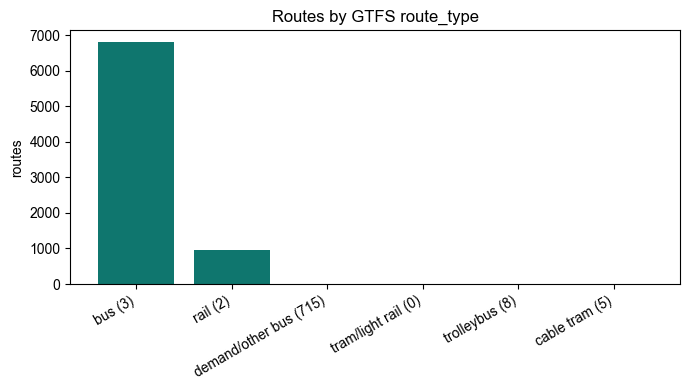

,route_type,route_type_label,routes,share
0,3,bus,6796,0.8722
1,2,rail,962,0.1235
2,715,demand/other bus,14,0.0018
3,0,tram/light rail,8,0.0010
4,8,trolleybus,8,0.0010
5,5,cable tram,4,0.0005


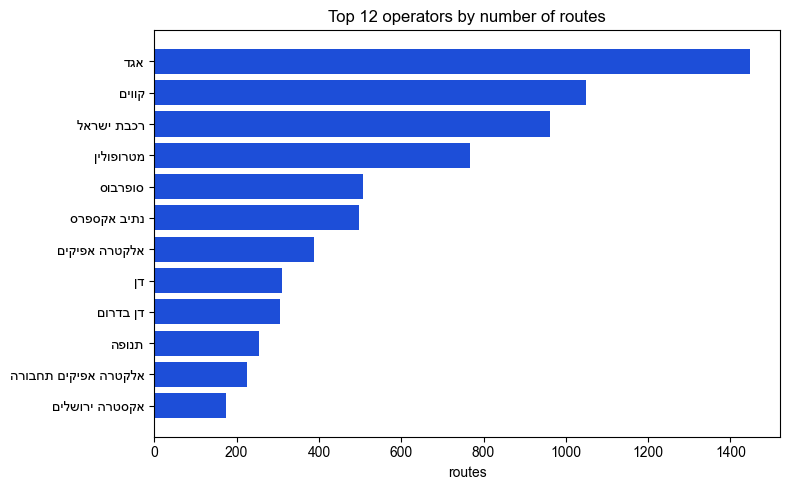

37 operators in the feed


,agency_name,routes
0,אגד,1448
1,קווים,1050
2,רכבת ישראל,962
3,מטרופולין,768
4,סופרבוס,508
5,נתיב אקספרס,497
6,אלקטרה אפיקים,387
7,דן,310
8,דן בדרום,305
9,תנופה,255


In [9]:
ROUTE_TYPE_LABELS = {
    "0": "tram/light rail", "1": "subway", "2": "rail", "3": "bus",
    "4": "ferry", "5": "cable tram", "6": "aerial lift", "7": "funicular",
    "8": "trolleybus", "715": "demand/other bus",
}

# --- routes per mode ---------------------------------------------------------
route_types = (routes["route_type"].value_counts()
               .rename_axis("route_type").reset_index(name="routes"))
route_types["route_type_label"] = route_types["route_type"].map(ROUTE_TYPE_LABELS).fillna("unknown")
route_types = route_types[["route_type", "route_type_label", "routes"]]
route_types["share"] = (route_types["routes"] / route_types["routes"].sum()).round(4)
route_types.to_csv(STAGE / "tables" / "route_type_distribution.csv",
                   index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(7, 4))
labels = route_types["route_type_label"] + " (" + route_types["route_type"] + ")"
ax.bar(labels, route_types["routes"], color="#0f766e")
ax.set_ylabel("routes")
ax.set_title("Routes by GTFS route_type")
ax.tick_params(axis="x", rotation=30)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
fig.tight_layout()
fig.savefig(STAGE / "figures" / "route_type_distribution.png", dpi=150)
plt.show()

display(route_types)

# --- routes per operator -----------------------------------------------------
agency_routes = (routes.merge(agency[["agency_id", "agency_name"]], on="agency_id", how="left")
                 .assign(agency_name=lambda d: d["agency_name"].replace("", "unknown"))
                 .groupby("agency_name").size()
                 .sort_values(ascending=False)
                 .rename("routes").reset_index())
agency_routes.to_csv(STAGE / "tables" / "agency_route_counts.csv",
                     index=False, encoding="utf-8-sig")

top = agency_routes.head(TOP_AGENCIES).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["agency_name"], top["routes"], color="#1d4ed8")
ax.set_xlabel("routes")
ax.set_title(f"Top {TOP_AGENCIES} operators by number of routes")
fig.tight_layout()
fig.savefig(STAGE / "figures" / "routes_per_agency.png", dpi=150)
plt.show()

print(f"{len(agency_routes)} operators in the feed")
display(agency_routes.head(TOP_AGENCIES))

## 11. A geographic sanity check

The last check is the most direct one: plot every stop by its longitude and latitude, with no map, no projection and no styling. If the coordinate columns are parsed correctly, the outline of Israel should simply appear - the dense coastal strip from Ashkelon through Tel Aviv to Haifa, the Jerusalem corridor branching inland, and the sparse Negev thinning out to the south.

This is genuinely useful validation and not just a nice picture: swapped lat/lon columns, a decimal-separator problem, or rows with default `0,0` coordinates would all show up here immediately and stay invisible in a table of summary statistics. We count how many stops have unusable coordinates instead of dropping them silently.

stops total              : 34,932
unparseable coordinates  : 0
outside the Israel bbox  : 0


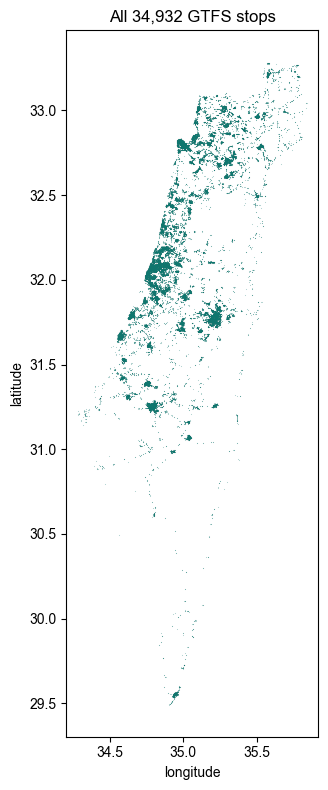

In [10]:
coords = stops.copy()
coords["stop_lat"] = pd.to_numeric(coords["stop_lat"], errors="coerce")
coords["stop_lon"] = pd.to_numeric(coords["stop_lon"], errors="coerce")

bad = coords["stop_lat"].isna() | coords["stop_lon"].isna()
out_of_range = (~bad) & ~(coords["stop_lat"].between(29, 34) & coords["stop_lon"].between(33, 36))
print(f"stops total              : {len(coords):,}")
print(f"unparseable coordinates  : {int(bad.sum()):,}")
print(f"outside the Israel bbox  : {int(out_of_range.sum()):,}")

plot_df = coords[~bad & ~out_of_range]
fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(plot_df["stop_lon"], plot_df["stop_lat"], s=0.6, alpha=0.35,
           color="#0f766e", linewidths=0)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"All {len(plot_df):,} GTFS stops")
ax.set_aspect(1.15)
fig.tight_layout()
fig.savefig(STAGE / "figures" / "stop_locations.png", dpi=150)
plt.show()

## 12. Writing the stage manifest

Finally we save a small JSON manifest describing the feed snapshot: the file inventory, the service window and the key counts. The later notebooks load it to report which snapshot their numbers came from, and it lets the whole series be traced back to one dated version of the data rather than "the GTFS feed" in the abstract.

Stage 00 deliberately produces no graph and no metric. Its only contract with the rest of the series is: the feed is on disk, it parses, and this is what's inside it.

In [11]:
manifest = {
    "stage": "00_setup_and_data",
    "data_dir": str(DATA),
    "feed_service_start": str(feed_start.date()),
    "feed_service_end": str(feed_end.date()),
    "feed_span_days": int(span_days),
    "files": int(len(inventory)),
    "total_size_mb": round(float(inventory["size_mb"].sum()), 2),
    "stop_times_rows": (None if pd.isna(inventory.set_index("file").loc["stop_times.txt", "rows"])
                        else int(inventory.set_index("file").loc["stop_times.txt", "rows"])),
    "stops": int(len(stops)),
    "routes": int(len(routes)),
    "agencies": int(len(agency)),
    "service_ids": int(len(calendar)),
    "route_type_counts": dict(zip(route_types["route_type_label"], route_types["routes"].astype(int))),
}

with (STAGE / "feed_manifest.json").open("w", encoding="utf-8") as fh:
    json.dump(manifest, fh, ensure_ascii=False, indent=2)

print(json.dumps(manifest, ensure_ascii=False, indent=2))
print("\nArtifacts written:")
for p in sorted(STAGE.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(STAGE).as_posix())

{
  "stage": "00_setup_and_data",
  "data_dir": "C:\\Users\\Sean-PC\\Desktop\\LAST SEMESTER\\אלגוריתמים ברשתות\\פרויקט גמר\\israel-public-transportation",
  "feed_service_start": "2026-04-19",
  "feed_service_end": "2026-05-19",
  "feed_span_days": 31,
  "files": 9,
  "total_size_mb": 836.23,
  "stop_times_rows": 15711624,
  "stops": 34932,
  "routes": 7792,
  "agencies": 37,
  "service_ids": 44770,
  "route_type_counts": {
    "bus": 6796,
    "rail": 962,
    "demand/other bus": 14,
    "tram/light rail": 8,
    "trolleybus": 8,
    "cable tram": 4
  }
}

Artifacts written:
   feed_manifest.json
   figures/route_type_distribution.png
   figures/routes_per_agency.png
   figures/stop_locations.png
   tables/agency_route_counts.csv
   tables/gtfs_file_inventory.csv
   tables/route_type_distribution.csv
   tables/service_calendar_summary.csv


## Conclusions

- The environment works. The dependency stack imports, the 816 MB `stop_times.txt` is on disk, all nine GTFS files parse, and Hebrew labels render in display order. Any failure later on is an analysis problem, not an installation one.
- The feed is a single snapshot, not "the network forever". `calendar.txt` gives an explicit validity window, and every conclusion in the later notebooks is scoped to it. The weekday profile shows the expected drop on Friday and Saturday, which is a good sign the data is complete.
- The network is overwhelmingly buses. Buses dominate the route count so heavily that the combined graph is, structurally, the bus graph. Heavy rail is a tiny fraction of the routes, which is exactly why it gets its own analysis instead of being read out of the national numbers, where it is statistically invisible.
- Only four of the nine files carry topology. `stop_times.txt`, `stops.txt`, `trips.txt` and `routes.txt` build the graph; `agency.txt` and `calendar.txt` give context; the two fare files and `translations.txt` are irrelevant to a connectivity question. A network weighted by fare or by travel time would be a different and also interesting study, but this project doesn't attempt that.
- One honest limitation, stated up front: the edges we're about to build encode service topology, not geography or travel time. An edge means "a scheduled vehicle runs directly from A to B", weighted by how many trips do so. It says nothing about how long that takes or the distance. Every centrality and resilience result in this series has to be read in those terms.